

# Clustering



**Clustering** é uma técnica de aprendizado de máquina **não supervisionado** que tem como objetivo agrupar um conjunto de objetos de tal forma que os objetos no mesmo grupo (ou cluster) sejam mais semelhantes entre si do que com os objetos de outros grupos.

Existem diversos algoritmos de clustering, cada um com suas próprias características e aplicações. Alguns dos algoritmos mais comuns incluem:

- **K-Means**: Um dos algoritmos de clustering mais populares, que particiona os dados em K clusters, onde cada cluster é representado pela média dos pontos dentro dele.
- **Hierarchical Clustering**: Cria uma hierarquia de clusters, que pode ser representada como uma árvore (dendrograma). Pode ser aglomerativo (bottom-up) ou divisivo (top-down).
- **DBSCAN**: Um algoritmo de clustering baseado em densidade que é capaz de encontrar clusters de forma arbitrária e lidar com ruídos.

O clustering é amplamente utilizado em diversas áreas, como segmentação de clientes, análise de redes sociais, reconhecimento de padrões e muito mais. Ele é especialmente útil quando não se tem rótulos ou categorias pré-definidas para os dados, permitindo que os próprios dados revelem suas estruturas subjacentes.

## K-Means

O algoritmo K-Means é um método de clustering que particiona os dados em $K$ clusters, onde cada cluster é representado pela média dos pontos dentro dele (**centroide**).

O algoritmo atribui cada ponto de dados ao cluster mais próximo com base em uma métrica de distância, geralmente a distância euclidiana. O objetivo do K-means é minimizar a soma dos quadrados das distâncias entre os pontos de dados e seus respectivos centroides, o que é conhecido como **within-cluster sum of squares (WCSS)**. Essa técnica é amplamente utilizada em análise de dados, reconhecimento de padrões e processamento de imagens devido à sua simplicidade e eficiência.

![](https://github.com/hsandmann/biblio/blob/main/ml/aula07/kmeans-illustration.png?raw=true)

### Conceitos-chave

- **Clusters**: Grupos de pontos de dados que são semelhantes entre si com base em uma métrica de distância.
- **Aprendizado Não Supervisionado**: O algoritmo funciona sem dados rotulados, identificando padrões apenas com base na estrutura dos dados.
- **Centroides**: São os "centros" dos clusters, representados pela média de todos os pontos em um cluster.
- **K**: O número de clusters, que deve ser especificado antecipadamente (por exemplo, K=3 significa dividir os dados em 3 clusters).
- **Métrica de Distância**: Normalmente, a distância euclidiana é usada para medir quão distante um ponto de dados está de um centróide. O objetivo é atribuir pontos ao centróide mais próximo.
- **Objetivo**: Minimizar a soma dos quadrados das distâncias dentro do cluster (WCSS - Within-Cluster Sum of Squares), que é a soma das distâncias ao quadrado entre cada ponto e seu centróide atribuído. Matematicamente, para um conjunto de dados e centróides, o objetivo é minimizar a função de custo. Exemplo, para o dataset $\textbf{X} = \{x_1, x_2, \dots, x_n\}$ e centroides $\mu=\{ \mu_1, \mu_2, \dots, \mu_n \}$, a função custo é:

    $$ \textbf{WCSS} = \arg \min_{\mu} \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2 $$

    onde $C_i$ é o conjunto de pontos no cluster $i$ e $\mu_i$ é o centróide do cluster $i$.

> K-Means assume que os clusters são esféricos e de tamanho semelhante, o que pode não ser adequado para todos os conjuntos de dados. Além disso, o algoritmo pode ser sensível a outliers e à escolha inicial dos centroides, o que pode levar a resultados subótimos. Para mitigar esses problemas, é comum executar o K-means várias vezes com diferentes inicializações e escolher a melhor solução com base na menor WCSS.

### Passo a passo

1. **Inicialização**:

    - Escolha o valor de $K$;
    
    - Aleatoriamento selecione o $K$ inicial do dataset.


2. **Atribuição**:

    - Para cada ponto do dataset, calcule a distância para todos os $k$-centroides;
    
    - Atribua o ponto ao cluster com o centróide mais próximo, com base na métrica de distância escolhida (geralmente a distância euclidiana).


3. **Atualização**:

    - Para cada cluster, recalcule os centroides dos clusters com base nos pontos atribuídos a cada cluster;
    
    - O novo centróide é a média dos pontos de dados em cada cluster.


4. **Iteração**:
    
    - Repita os passos de atribuição (passo 2) e atualização até atingir um dos critérios de parada:
    
        - os centroides não mudem mais (ou a mudança é menor que um limiar - threshold, e.g., 0.001);

        - até atingir um número máximo de iterações (para evitar loops infinitos);
        
        - quando o WCSS cai minimamento entre as iterações.


5. **Saída**:

    - As cetroides definidas;

    - As atribuições de cluster para ponto do dataset.

### Exemplo Numérico

Dado um dataset de 2-dimensões (2-features), com 5 exemplos:

$$
\begin{bmatrix}
1 & 2 \\
2 & 1 \\
5 & 8 \\
6 & 7 \\
8 & 6
\end{bmatrix}
$$

Vamos assumir $k = 2$.

- **Inicialização**: aleatoriamente escolhemos os centroides, e.g.: $C_1=(1, 2)$ e $C_2=(5,8)$.

- **Atribuição**:

    - $(1, 2)$ e $(2, 1)$ estão mais próximos de $C_1$ $\implies$ Cluster 1.

    - $(5, 8)$, $(6, 7)$ e $(8, 6)$ estão mais próximos de $C_2$ $\implies$ Cluster 2.

- **Atualização**:

    - $C_1$ = média entre $(1, 2)$ e $(2, 1)$ = $(1.5, 1.5)$;

    - $C_e$ = média entre $(5, 8)$, $(6, 7)$ e $(8, 6)$ = $(6.33, 7)$.

- **Iteração**:

    - Reatribuir os pontos aos novos centroides;

    - Repita os passos de 2 e 3 até uma estabilização.

Para o exemplo, após a convergência, teremos dois clusters, com centroides em $(1.5, 1.5)$ e $(6.33, 7)$.

### Vantagens e Desvantagens

| Aspecto | Vantagens | Desvantagens |
|---|---|---|
| **Simplicidade** | Fácil de entender e implementar; computacionalmente eficiente ($O(n)$ por iteração). | Sensível ao centróide inicial; pode converter para um *ótimo-local*. |
| **Escalabidade** | Funciona bem com datasets grandes, apresenta complexidade de tempo linear. | Assume que os cluster são esféricos; tem dificuldades com densidades não convexas ou variáveis. |
| **Saída** | Produz agrupamentos compactos e densos; centroides interpretáveis. | Requer um valor K predefinido; valores discrepantes podem distorcer os resultados. |

### Escolhendo $K$

#### **Método do cotovelo** (Elbow Method):

Plote WCSS vs. $K$ e procure por um **cotovelo** onde a taxa de decaimento caí devagar.

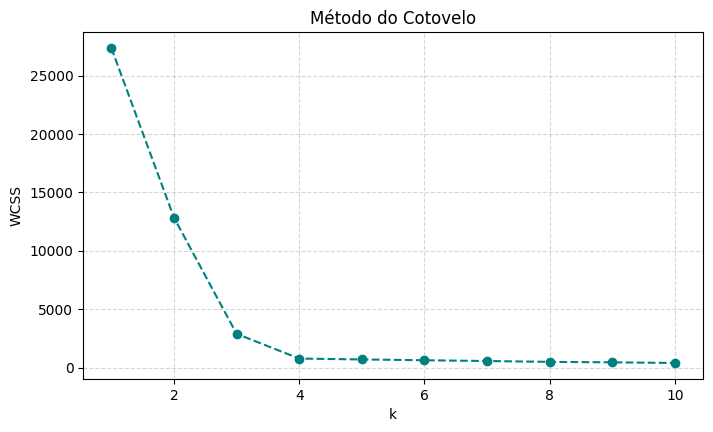

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=400, centers=4, random_state=42)
inertias = [KMeans(k, n_init=10, random_state=42).fit(X).inertia_ for k in range(1,11)]

plt.figure(figsize=(8,4.5))
plt.plot(range(1,11), inertias, 'o--', color='teal')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('Método do Cotovelo')
plt.grid(True, ls='--', alpha=0.5)
plt.show()

#### **Método da Silhueta** (Silhouette Score):

A silhueta mede quão bem cada exemplo está agrupado em relação aos outros clusters.

Ela combina duas ideias:

- **a** = quão próximo o exemplo está dos outros exemplos do mesmo cluster (quanto menor → melhor, cluster compacto);

- **b** = quão distante o exemplo está do cluster mais próximo diferente do seu (quanto maior → melhor, boa separação).

A fórmula do coeficiente de silhueta para um exemplo $i$ é:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Intervalo: $−1 \leq s(i) \leq +1$

| score | significado |
|--:|---|
| $\approx +1$ | exemplo muito bem classificado (muito dentro do seu cluster e longe dos outros) |
| $\approx 0$ | exemplo na fronteira entre dois clusters |
| $ < 0$ | exemplo provavelmente está no cluster errado |



##### **Passo a passo**

Para cada exemplo $i$ no dataset:

- a. Calcule $a(i)$: distância média entre o exemplo $i$ e todos os outros exemplos do mesmo cluster:

    $a(i) = \displaystyle \frac{1}{|C_i| - 1} \sum_{j \in C_i, j \neq i} d(i,j)$

    (onde $C_i$ é número de exemplos do cluster que contém o exemplo $i$, $d$ é a distância — normalmente Euclidiana)
    
- b. Calcule $b(i)$: distância média entre o exemplo $i$ e todos os exemplos do cluster mais próximo diferente do seu.

    Para cada cluster diferente de $C_i$:

    - calcule a distância média de $i$ para todos os pontos daquele cluster;

    - pegue o menor desses valores médios → esse é $b(i)$

        $b(i) = \displaystyle \min_{C_k \neq C_i} \left( \frac{1}{|C_k|} \sum_{j \in C_k} d(i,j) \right)$

Calcule $s(i)$ para cada ponto:

$$s(i) =
\begin{cases}
1 - \frac{a(i)}{b(i)} & \text{se } a(i) < b(i) \\
0 & \text{se } a(i) = b(i) \\
\frac{b(i)}{a(i)} - 1 & \text{se } a(i) > b(i)
\end{cases}$$

Ou, de forma equivalente e mais usada na prática:$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
Silhouette Score médio do modelo (o valor que plotamos no método da silhueta):

$$S = \frac{1}{N} \sum_{i=1}^N s(i)$$

onde $N$ é o número total de exemplos.


##### **Resultado**

| Situação | Interpretação da Silhueta média | Ação sugerida |
|--:|---|---|
| $> 0.7$ | Estrutura muito forte | Excelente agrupamento |
| $(0.5; 0.7]$ | Estrutura razoável | Bom agrupamento |
| $(0.25; 0.5]$ | Estrutura fraca | Talvez aceitável |
| $[0; 0.25]$ | Sem estrutura significativa | Talvez K-Means não seja adequado |
| $<0$ | Muitos pontos mal classificados | Tente outro $k$ ou outro algoritmo |

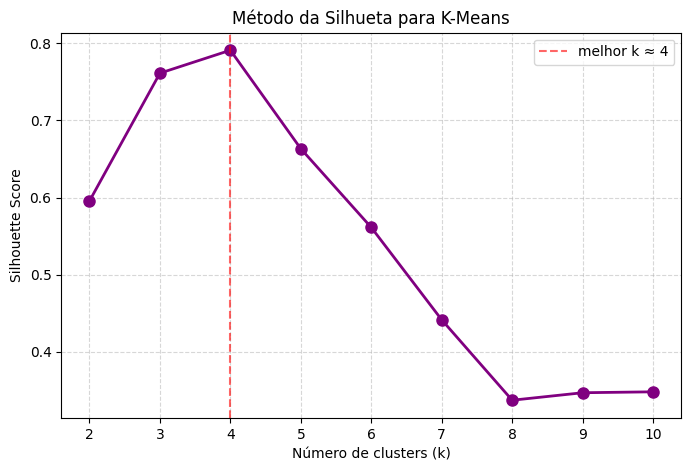

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=4, random_state=42)

scores = [silhouette_score(X, KMeans(k, n_init=10, random_state=42).fit_predict(X))
          for k in range(2, 11)]

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), scores, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método da Silhueta para K-Means')
plt.grid(True, ls='--', alpha=0.5)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='melhor k ≈ 4')
plt.legend()
plt.show()

#### **Comparação**

|Critério|Método do Cotovelo (Elbow)|Método da Silhueta (Silhouette)|Vencedor (na maioria dos casos)|
|---|---|---|---|
| O que mede|Redução da inércia (soma dos quadrados intra-cluster – WCSS)|Qualidade da separação e coesão dos clusters (média do coeficiente de silhueta por ponto)|—|
| Intervalo de valores|Inércia: sempre positiva e decrescente|Silhueta média: -1 a +1|—|
| Facilidade de interpretação| Inspeção visual (procura o "cotovelo")|Mais objetivo: maior valor = melhor k|Silhueta|
| Facilidade de automação|Difícil (o cotovelo nem sempre é claro/obvio)|Fácil (basta pegar o k com maior score)|Silhueta|
| Sensibilidade a ruído / outliers|Moderada (inércia é sensível a pontos distantes)|Alta (pontos mal classificados ou outliers puxam o score para baixo)|Cotovelo (ligeira vantagem)|
| Funciona bem quando clusters têm tamanhos parecidos|Sim|Sim|Empate|
| Funciona bem quando clusters têm tamanhos muito diferentes|Geralmente sim|Pode falhar (clusters pequenos podem ter silhueta baixa mesmo sendo bons)|Cotovelo|
| Funciona bem em clusters com densidades diferentes|Sim|Pode subestimar clusters densos vs. esparsos|Cotovelo|
| Funciona bem em dados de alta dimensionalidade|Razoável|Pode ser enganoso (maldição da dimensionalidade afeta distâncias)|Cotovelo (mais robusto)|
| Custo computacional|Baixo (só calcula inércia)|Médio-alto (precisa calcular distâncias entre todos os pontos e clusters vizinhos)|Cotovelo|
| "Quando o ""melhor k"" é óbvio"|Muito bom (curva clara)|Excelente (score alto e destacado)|Empate|
| Quando não existe cotovelo claro|Fraco (muitas interpretações possíveis)|Melhor (ainda fornece um máximo mensurável)|Silhueta|
| Indica clusters mal formados|Não diretamente|Sim (score médio baixo ou muitos valores negativos)|Silhueta|
| Recomendação geral de uso|"Primeira análise rápida| dados com clusters bem separados e tamanhos semelhantes"|"Análise mais confiável| quando se quer maximizar separação/coesão"|—|

## Exercícios

1. Aplique K-Means ao [Iris Dataset](https://www.kaggle.com/datasets/uciml/iris).

    - Remova os targets;
    - Pré-processe os dados;
    - Obtenha o resultado de clustering e compare com os dados já classificados.

2. Sobre o exercício anterior, varie o número de $K$, no mínimo $K = \{1, 2, \dots, 10 \}$.

    - Usado o método do cotovelo, plote o gráfico da variação da WCSS;

    - Usado o método da silhueta, plote o gráfico da variação da média da silhueta;

    - Analise os dados sem *bias* de conhecimento prévio dos dados.

3. Agora, gerando dados sintéticos $N>=500$, variando $K = \{2, 3, 4, 5, 6, 7\}$, variando as centroides iniciais (no mínimo 3 vezes por configuração), em 2D:

    - aplique K-Means para seguintes configurações de experimentos:

        - 4 classes balanceadas, distribuição em clusters com $\text{std} = 0.9$ (vide [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html));

        - 2 classes balanceadas, distribuição em clusters globulares, com $\text{ruído}=0.05$ (vide [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html)).

        - 4 classes balanceadas, distribuição aleatória.

    - comente erros e acertos de cada experimento;

4. Pesquise sobre inicialização **K-Means++**.

# Adicional

[![](https://img.youtube.com/vi/njRYKzRKBPY/maxresdefault.jpg)](https://youtu.be/njRYKzRKBPY)

YouTube: [Algoritmo k-means (k-médias)](https://youtu.be/njRYKzRKBPY)